In [1]:
import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# =====================================================
# 1. LEITURA
# =====================================================

df1 = pd.read_excel(
    "INDICADORES MENSAIS POR UNIVERSO.xlsx",
    engine="openpyxl"
)

df2 = pd.read_excel(
    "INDICADORES MENSAIS POR UNIVERSO (2).xlsx",
    engine="openpyxl"
)

df3 = pd.read_excel(
    "INDICADORES MENSAIS POR UNIVERSO (3).xlsx",
    engine="openpyxl"
)

df4 = pd.read_excel(
    "INDICADORES MENSAIS POR UNIVERSO (4).xlsx",
    engine="openpyxl"
)

ams = pd.read_csv("AMS_ativos_mina.csv")
amc = pd.read_csv("AMC_ativos_mina.csv")
apr = pd.read_csv("APR_ativos_mina.csv")
backlog = pd.read_csv("Backlog_imos_ativos_mina.csv")

df = pd.concat(
    [df1, df2, df3, df4],
    ignore_index=True
)


c:\Program Files\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Program Files\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Program Files\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [3]:
# =====================================================
# 2. FUNÇÕES
# =====================================================

def corrigir_numero(col):

    return pd.to_numeric(
        col.astype(str)
           .str.replace(",", ".", regex=False),
        errors="coerce"
    )

# =====================================================
# COLUNAS NUMÉRICAS BACKLOG
# =====================================================

cols_backlog = [

    "hh_em_ordens_vencidas",

    "hh_em_ordens_vencidas_ypm",
    "hh_em_ordens_ypm",

    "hh_em_ordens_vencidas_ycm",
    "hh_em_ordens_ycm",

    "hh_em_ordens_vencidas_corretiva",
    "hh_em_ordens_corretivas",

    "hh_em_ordens_vencidas_prio1",
    "hh_em_ordens_prio1",

    "hh_em_ordens_prio2",
    "hh_em_ordens_vencidas_prio2"

]

for col in cols_backlog:

    backlog[col] = corrigir_numero(
        backlog[col]
    )

# =====================================================
# VALIDAÇÃO
# =====================================================

print("\n====================")
print("DTYPES")
print("====================")

print(
    backlog[
        ["HH_EM CARTEIRA"] + cols_backlog
    ].dtypes
)

print("\n====================")
print("DESCRIBE")
print("====================")

print(
    backlog[
        ["HH_EM CARTEIRA"] + cols_backlog
    ].describe()
)


DTYPES
HH_EM CARTEIRA                     float64
hh_em_ordens_vencidas              float64
hh_em_ordens_vencidas_ypm          float64
hh_em_ordens_ypm                   float64
hh_em_ordens_vencidas_ycm          float64
hh_em_ordens_ycm                   float64
hh_em_ordens_vencidas_corretiva    float64
hh_em_ordens_corretivas            float64
hh_em_ordens_vencidas_prio1        float64
hh_em_ordens_prio1                 float64
hh_em_ordens_prio2                 float64
hh_em_ordens_vencidas_prio2        float64
dtype: object

DESCRIBE
       HH_EM CARTEIRA  hh_em_ordens_vencidas  hh_em_ordens_vencidas_ypm  \
count     7001.000000             2073.00000                 626.000000   
mean       261.846905               86.19055                  54.072843   
std        407.216652              113.34296                  91.345964   
min          0.000000                0.00000                   0.000000   
25%         14.200000               12.80000                   4.000000   
50

In [4]:
NIVEL_HIERARQUIA = -2
# =====================================================
# FUNÇÃO EXTRAÇÃO HIERARQUIA
# =====================================================

def extrair_grupo(col):

    partes = col.astype(str).str.split("-")

    return partes.str[NIVEL_HIERARQUIA]

In [5]:
# =====================================================
# VALIDAÇÃO NÍVEL HIERÁRQUICO -2
# =====================================================

nivel_teste = -2

grupos = (
    ams["TPLNR05"]
    .astype(str)
    .str.split("-")
    .str[nivel_teste]
)

print("\n====================")
print("NÍVEL TESTADO")
print("====================")
print(nivel_teste)

print("\n====================")
print("GRUPOS MAIS FREQUENTES")
print("====================")
print(
    grupos
    .value_counts()
    .head(30)
)

print("\n====================")
print("ESTATÍSTICAS")
print("====================")

contagem = grupos.value_counts()

print(contagem.describe())

print("\n====================")
print("QUANTIDADE DE GRUPOS")
print("====================")

print(contagem.shape[0])

print("\n====================")
print("AMOSTRA DE GRUPOS")
print("====================")

print(
    sorted(
        grupos.dropna().unique()
    )[:50]
)


NÍVEL TESTADO
-2

GRUPOS MAIS FREQUENTES
TPLNR05
CAM65    2584
CAM70    2350
CAM57    1252
TES48     614
TANIR     514
PER11     514
MTN16     440
VMEDI     435
L1850     369
TESD5     333
G3505     276
CAVMC     240
PCP41     202
PER67     175
TES23     134
P5500     121
TES47     115
RETRO     114
PCP42     104
TPN47      88
ROC8H      88
CAM67      77
ESC36      77
TPN51      60
TES46      43
ESC33      41
MTN17      39
G5505      34
TES22      25
BRITA      18
Name: count, dtype: int64

ESTATÍSTICAS
count      43.000000
mean      268.627907
std       545.833222
min         1.000000
25%        14.000000
50%        77.000000
75%       258.000000
max      2584.000000
Name: count, dtype: float64

QUANTIDADE DE GRUPOS
43

AMOSTRA DE GRUPOS
['ALIME', 'ARCOM', 'BRIT3', 'BRITA', 'CAM57', 'CAM65', 'CAM67', 'CAM70', 'CAVMC', 'COMMG', 'DRGDL', 'EMPIL', 'ESC33', 'ESC36', 'FILVT', 'FLOCV', 'G3505', 'G5505', 'L1850', 'M6420', 'MOIBO', 'MTN16', 'MTN17', 'P5500', 'PCP41', 'PCP42', 'PENEI', 'PER09

In [6]:
# =====================================================
# 3. PADRONIZAÇÃO
# =====================================================

for tabela in [df, ams, amc, apr, backlog]:

    tabela.columns = tabela.columns.str.strip()

for tabela in [ams, amc, apr, backlog]:

    tabela["GRUPO"] = extrair_grupo(
        tabela["TPLNR05"]
    )

    tabela.rename(
        columns={
            "CALMONTH-Calendar_year_month":
            "ANO MÊS"
        },
        inplace=True
    )

apr.rename(
    columns={
        ".APR": "APR"
    },
    inplace=True
)

for tabela in [ams, amc, apr, backlog]:

    tabela["ANO MÊS"] = pd.to_datetime(
        tabela["ANO MÊS"].astype(str),
        format="%Y%m"
    )
df["ANO MÊS"] = pd.to_datetime(
    df["ANO MÊS"].astype(str),
    format="%Y%m",
    errors="coerce"
)

df = df.dropna(
    subset=["ANO MÊS"]
)

In [7]:
print(df["ANO MÊS"].min(), df["ANO MÊS"].max())
print(ams["ANO MÊS"].min(), ams["ANO MÊS"].max())
print(backlog["ANO MÊS"].min(), backlog["ANO MÊS"].max())

2025-01-01 00:00:00 2026-06-01 00:00:00
2025-03-01 00:00:00 2026-06-01 00:00:00
2025-03-01 00:00:00 2026-06-01 00:00:00


In [8]:
# =====================================================
# MAPA EQUIPAMENTO -> GRUPO
# =====================================================

mapa_grupo = (
    ams[["TPLNR05"]]
    .drop_duplicates()
)

partes = (
    mapa_grupo["TPLNR05"]
    .astype(str)
    .str.split("-")
)

mapa_grupo["EQUIPAMENTO"] = (
    partes.str[-1]
)

mapa_grupo["GRUPO"] = (
    partes.str[NIVEL_HIERARQUIA]
)

mapa_grupo = (
    mapa_grupo[
        [
            "EQUIPAMENTO",
            "GRUPO"
        ]
    ]
    .drop_duplicates()
)

print("\nValidação equipamento -> grupo")

print(
    mapa_grupo
    .groupby("EQUIPAMENTO")
    ["GRUPO"]
    .nunique()
    .value_counts()
)

print("\nExemplos de grupos")

print(
    mapa_grupo
    .sample(
        min(
            20,
            len(mapa_grupo)
        ),
        random_state=42
    )
)


Validação equipamento -> grupo
GRUPO
1    317
Name: count, dtype: int64

Exemplos de grupos
        EQUIPAMENTO  GRUPO
73          CA70959  CAM70
6742         CT6170  TANIR
25          CE57820  CAM57
5659         CT6230  VMEDI
9            CT6160  TANIR
190          MN1166  MTN16
1125         RE3431  RETRO
1797        CA65920  CAM65
63           CA6001  CAM70
291    BR_1210CN_01  BRITA
4936     21BO093325  COMMG
75          CA70961  CAM70
726          PE3795  L1850
1036         EM2970  P5500
4663         CB7341  VMEDI
84           PM4162  PCP41
1796        CA65918  CAM65
375         CA70955  CAM70
11224        EP6910  VMEDI
4933         EP6904  VMEDI


In [9]:
# =====================================================
# QUANTIDADE DE EQUIPAMENTOS POR GRUPO
# =====================================================

qtd_ativos = (

    mapa_grupo

    .groupby("GRUPO", as_index=False)

    .agg({
        "EQUIPAMENTO": "nunique"
    })

    .rename(
        columns={
            "EQUIPAMENTO":
            "QTD_ATIVOS"
        }
    )

)

print("\nQuantidade de ativos por grupo")

print(qtd_ativos.head())


Quantidade de ativos por grupo
   GRUPO  QTD_ATIVOS
0  ALIME           1
1  ARCOM           1
2  BRIT3           1
3  BRITA          14
4  CAM57          12


In [10]:
# =====================================================
# 5. ASSOCIAR GRUPO AO DF
# =====================================================

df = df.merge(
    mapa_grupo,
    on="EQUIPAMENTO",
    how="left"
)

print("\nCobertura do mapa")

print(
    df["GRUPO"]
    .isna()
    .mean()
)



Cobertura do mapa
0.012392755004766444


In [11]:
# =====================================================
# 7. NUMÉRICOS
# =====================================================

# DF / CONFIABILIDADE

for col in [
    "DF (REAL)",
    "MTBF (REAL)",
    "MTBS (REAL)",
    "MTTR",
    "NIC (VMINA)"
]:
    df[col] = corrigir_numero(df[col])

# =====================================================
# AMS
# =====================================================

for col in [
    "AMS_00H",
    "Soma de IMAINDI383-Number_of_orders_with_meter_based_plan",
    "Soma de IMAINDI384-Number_of_closed_orders_with_meter_based_plan"
]:
    ams[col] = corrigir_numero(ams[col])

# =====================================================
# AMC
# =====================================================

for col in [
    "AMC_00I",
    "Soma de IMAINDI189_ACTUAL_NA-Number_of_planned_notification_for_month NA"
]:
    amc[col] = corrigir_numero(amc[col])

# =====================================================
# APR
# =====================================================

for col in [
    "APR",
    "Soma de IMAINDI64_TOT"
]:
    apr[col] = corrigir_numero(apr[col])

# =====================================================
# BACKLOG
# =====================================================

for col in [

    "HH_EM CARTEIRA",
    "hh_em_ordens_vencidas",

    "hh_em_ordens_vencidas_ypm",
    "hh_em_ordens_ypm",

    "hh_em_ordens_vencidas_ycm",
    "hh_em_ordens_ycm",

    "hh_em_ordens_vencidas_corretiva",
    "hh_em_ordens_corretivas",

    "hh_em_ordens_vencidas_prio1",
    "hh_em_ordens_prio1",

    "hh_em_ordens_prio2",
    "hh_em_ordens_vencidas_prio2"

]:
    backlog[col] = corrigir_numero(backlog[col])

# =====================================================
# VALIDAÇÃO
# =====================================================

print("\nDF")
print(
    df[
        [
            "DF (REAL)",
            "MTBF (REAL)",
            "MTBS (REAL)",
            "MTTR",
            "NIC (VMINA)"
        ]
    ].dtypes
)

print("\nBACKLOG")
print(
    backlog[
        [
            "HH_EM CARTEIRA",
            "hh_em_ordens_vencidas",
            "hh_em_ordens_vencidas_ypm",
            "hh_em_ordens_ypm",
            "hh_em_ordens_vencidas_ycm",
            "hh_em_ordens_ycm",
            "hh_em_ordens_vencidas_corretiva",
            "hh_em_ordens_corretivas",
            "hh_em_ordens_vencidas_prio1",
            "hh_em_ordens_prio1",
            "hh_em_ordens_prio2",
            "hh_em_ordens_vencidas_prio2"
        ]
    ].dtypes
)


DF
DF (REAL)      float64
MTBF (REAL)    float64
MTBS (REAL)    float64
MTTR           float64
NIC (VMINA)    float64
dtype: object

BACKLOG
HH_EM CARTEIRA                     float64
hh_em_ordens_vencidas              float64
hh_em_ordens_vencidas_ypm          float64
hh_em_ordens_ypm                   float64
hh_em_ordens_vencidas_ycm          float64
hh_em_ordens_ycm                   float64
hh_em_ordens_vencidas_corretiva    float64
hh_em_ordens_corretivas            float64
hh_em_ordens_vencidas_prio1        float64
hh_em_ordens_prio1                 float64
hh_em_ordens_prio2                 float64
hh_em_ordens_vencidas_prio2        float64
dtype: object


In [12]:
print(
    ams[
        [
            "AMS_00H",
            "Soma de IMAINDI383-Number_of_orders_with_meter_based_plan",
            "Soma de IMAINDI384-Number_of_closed_orders_with_meter_based_plan"
        ]
    ].dtypes
)

AMS_00H                                                             float64
Soma de IMAINDI383-Number_of_orders_with_meter_based_plan             int64
Soma de IMAINDI384-Number_of_closed_orders_with_meter_based_plan      int64
dtype: object


In [13]:
# =====================================================
# VARIÁVEIS DERIVADAS DE NEGÓCIO
# =====================================================
# =====================================================
# AMS
# =====================================================

ams["AMS_PREVISTAS"] = ams[
    "Soma de IMAINDI383-Number_of_orders_with_meter_based_plan"
]

ams["AMS_EXECUTADAS"] = ams[
    "Soma de IMAINDI384-Number_of_closed_orders_with_meter_based_plan"
]

ams["AMS_PENDENTES"] = (
    ams["AMS_PREVISTAS"]
    -
    ams["AMS_EXECUTADAS"]
)

ams["AMS_PCT_PENDENTE"] = np.where(
    ams["AMS_PREVISTAS"] > 0,
    ams["AMS_PENDENTES"]
    /
    ams["AMS_PREVISTAS"],
    np.nan
)

# =====================================================
# AMC
# =====================================================

amc["AMC_PREVISTAS"] = amc[
    "Soma de IMAINDI189_ACTUAL_NA-Number_of_planned_notification_for_month NA"
]

amc["AMC_EXECUTADAS"] = (
    amc["AMC_PREVISTAS"]
    *
    amc["AMC_00I"]
    /
    100
)

amc["AMC_NAO_ADERENTES"] = (
    amc["AMC_PREVISTAS"]
    -
    amc["AMC_EXECUTADAS"]
)

amc["AMC_PCT_NAO_ADERENTE"] = np.where(
    amc["AMC_PREVISTAS"] > 0,
    amc["AMC_NAO_ADERENTES"]
    /
    amc["AMC_PREVISTAS"],
    np.nan
)

# =====================================================
# APR
# =====================================================

apr["APR_PREVISTAS"] = apr[
    "Soma de IMAINDI64_TOT"
]

apr["APR_EXECUTADAS"] = (
    apr["APR_PREVISTAS"]
    *
    apr["APR"]
    /
    100
)

apr["APR_NAO_ADERENTES"] = (
    apr["APR_PREVISTAS"]
    -
    apr["APR_EXECUTADAS"]
)

apr["APR_PCT_NAO_ADERENTE"] = np.where(
    apr["APR_PREVISTAS"] > 0,
    apr["APR_NAO_ADERENTES"]
    /
    apr["APR_PREVISTAS"],
    np.nan
)

# =====================================================
# BACKLOG
# =====================================================

backlog["BACKLOG_TOTAL"] = backlog[
    "HH_EM CARTEIRA"
]

backlog["BACKLOG_VENCIDO"] = backlog[
    "hh_em_ordens_vencidas"
]

backlog["BACKLOG_PCT_VENCIDO"] = np.where(
    backlog["BACKLOG_TOTAL"] > 0,
    backlog["BACKLOG_VENCIDO"]
    /
    backlog["BACKLOG_TOTAL"],
    np.nan
)

# =====================================================
# YPM
# =====================================================

backlog["BACKLOG_PCT_YPM_VENCIDO"] = np.where(
    backlog["hh_em_ordens_ypm"] > 0,
    backlog["hh_em_ordens_vencidas_ypm"]
    /
    backlog["hh_em_ordens_ypm"],
    np.nan
)

# =====================================================
# YCM
# =====================================================

backlog["BACKLOG_PCT_YCM_VENCIDO"] = np.where(
    backlog["hh_em_ordens_ycm"] > 0,
    backlog["hh_em_ordens_vencidas_ycm"]
    /
    backlog["hh_em_ordens_ycm"],
    np.nan
)

# =====================================================
# CORRETIVA
# =====================================================

backlog["BACKLOG_PCT_CORRETIVA_VENCIDO"] = np.where(
    backlog["hh_em_ordens_corretivas"] > 0,
    backlog["hh_em_ordens_vencidas_corretiva"]
    /
    backlog["hh_em_ordens_corretivas"],
    np.nan
)

# =====================================================
# PRIORIDADE 1
# =====================================================

backlog["BACKLOG_PCT_PRIO1_VENCIDO"] = np.where(
    backlog["hh_em_ordens_prio1"] > 0,
    backlog["hh_em_ordens_vencidas_prio1"]
    /
    backlog["hh_em_ordens_prio1"],
    np.nan
)

# =====================================================
# PRIORIDADE 2
# =====================================================

backlog["BACKLOG_PCT_PRIO2_VENCIDO"] = np.where(
    backlog["hh_em_ordens_prio2"] > 0,
    backlog["hh_em_ordens_vencidas_prio2"]
    /
    backlog["hh_em_ordens_prio2"],
    np.nan
)

# =====================================================
# EVOLUÇÃO DO BACKLOG
# =====================================================

backlog = backlog.sort_values(
    [
        "TPLNR05",
        "ANO MÊS"
    ]
)

backlog["BACKLOG_DELTA"] = (
    backlog
    .groupby("TPLNR05")["BACKLOG_TOTAL"]
    .diff()
)

backlog["BACKLOG_CRESCIMENTO"] = (
    backlog
    .groupby("TPLNR05")["BACKLOG_TOTAL"]
    .pct_change()
)

# =====================================================
# VALIDAÇÃO
# =====================================================

print("\nAMS")
print(
    ams[
        [
            "AMS_PREVISTAS",
            "AMS_EXECUTADAS",
            "AMS_PENDENTES",
            "AMS_PCT_PENDENTE"
        ]
    ].describe()
)

print("\nAMC")
print(
    amc[
        [
            "AMC_PREVISTAS",
            "AMC_EXECUTADAS",
            "AMC_NAO_ADERENTES",
            "AMC_PCT_NAO_ADERENTE"
        ]
    ].describe()
)

print("\nAPR")
print(
    apr[
        [
            "APR_PREVISTAS",
            "APR_EXECUTADAS",
            "APR_NAO_ADERENTES",
            "APR_PCT_NAO_ADERENTE"
        ]
    ].describe()
)

print("\nBACKLOG")
print(
    backlog[
        [
            "BACKLOG_TOTAL",
            "BACKLOG_VENCIDO",
            "BACKLOG_PCT_VENCIDO",
            "BACKLOG_PCT_YPM_VENCIDO",
            "BACKLOG_PCT_YCM_VENCIDO",
            "BACKLOG_PCT_CORRETIVA_VENCIDO",
            "BACKLOG_PCT_PRIO1_VENCIDO",
            "BACKLOG_PCT_PRIO2_VENCIDO",
            "BACKLOG_DELTA",
            "BACKLOG_CRESCIMENTO"
        ]
    ].describe()
)


AMS
       AMS_PREVISTAS  AMS_EXECUTADAS  AMS_PENDENTES  AMS_PCT_PENDENTE
count   11582.000000     11582.00000   11582.000000      11582.000000
mean        2.283630         2.14652       0.137109          0.044208
std         2.016281         1.82605       0.627237          0.178270
min         1.000000         0.00000       0.000000          0.000000
25%         1.000000         1.00000       0.000000          0.000000
50%         1.000000         1.00000       0.000000          0.000000
75%         3.000000         3.00000       0.000000          0.000000
max        24.000000        14.00000      13.000000          1.000000

AMC
       AMC_PREVISTAS  AMC_EXECUTADAS  AMC_NAO_ADERENTES  AMC_PCT_NAO_ADERENTE
count    3307.000000     3307.000000        3307.000000           3307.000000
mean        8.788630        6.216434           2.572196              0.345075
std         8.757043        7.060435           3.064808              0.332835
min         1.000000        0.000000           0

c:\Program Files\Python313\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [14]:
# =====================================================
# 8. COLUNAS
# =====================================================

ams = ams[
    [
        "ANO MÊS",
        "GRUPO",

        "AMS_00H",

        "AMS_PREVISTAS",
        "AMS_EXECUTADAS",
        "AMS_PENDENTES",
        "AMS_PCT_PENDENTE"
    ]
]

amc = amc[
    [
        "ANO MÊS",
        "GRUPO",

        "AMC_00I",

        "AMC_PREVISTAS",
        "AMC_EXECUTADAS",
        "AMC_NAO_ADERENTES",
        "AMC_PCT_NAO_ADERENTE"
    ]
]

apr = apr[
    [
        "ANO MÊS",
        "GRUPO",

        "APR",

        "APR_PREVISTAS",
        "APR_EXECUTADAS",
        "APR_NAO_ADERENTES",
        "APR_PCT_NAO_ADERENTE"
    ]
]

backlog = backlog[
    [
        "ANO MÊS",
        "GRUPO",

        "BACKLOG_TOTAL",
        "BACKLOG_VENCIDO",
        "BACKLOG_PCT_VENCIDO",

        "BACKLOG_PCT_YPM_VENCIDO",
        "BACKLOG_PCT_YCM_VENCIDO",
        "BACKLOG_PCT_CORRETIVA_VENCIDO",
        "BACKLOG_PCT_PRIO1_VENCIDO",
        "BACKLOG_PCT_PRIO2_VENCIDO",

        "BACKLOG_DELTA",
        "BACKLOG_CRESCIMENTO"
    ]
]

In [15]:
# =====================================================
# 9. AGREGAÇÃO POR GRUPO
# =====================================================

df_grupo = (

    df

    .groupby(
        [
            "ANO MÊS",
            "GRUPO"
        ],
        as_index=False
    )

    .agg({

        "DF (REAL)": "mean",

        "MTBF (REAL)": "mean",

        "MTBS (REAL)": "mean",

        "MTTR": "mean",

        "NIC (VMINA)": "mean"

    })

)

# =====================================================
# AMS
# =====================================================

ams_grupo = (

    ams

    .groupby(
        [
            "ANO MÊS",
            "GRUPO"
        ],
        as_index=False
    )

    .agg({

        "AMS_00H": "mean",

        "AMS_PREVISTAS": "sum",
        "AMS_EXECUTADAS": "sum",
        "AMS_PENDENTES": "sum",

        "AMS_PCT_PENDENTE": "mean"

    })

)

# =====================================================
# AMC
# =====================================================

amc_grupo = (

    amc

    .groupby(
        [
            "ANO MÊS",
            "GRUPO"
        ],
        as_index=False
    )

    .agg({

        "AMC_00I": "mean",

        "AMC_PREVISTAS": "sum",
        "AMC_EXECUTADAS": "sum",
        "AMC_NAO_ADERENTES": "sum",

        "AMC_PCT_NAO_ADERENTE": "mean"

    })

)

# =====================================================
# APR
# =====================================================

apr_grupo = (

    apr

    .groupby(
        [
            "ANO MÊS",
            "GRUPO"
        ],
        as_index=False
    )

    .agg({

        "APR": "mean",

        "APR_PREVISTAS": "sum",
        "APR_EXECUTADAS": "sum",
        "APR_NAO_ADERENTES": "sum",

        "APR_PCT_NAO_ADERENTE": "mean"

    })

)

# =====================================================
# BACKLOG
# =====================================================

backlog_grupo = (

    backlog

    .groupby(
        [
            "ANO MÊS",
            "GRUPO"
        ],
        as_index=False
    )

    .agg({

        "BACKLOG_TOTAL": "sum",

        "BACKLOG_VENCIDO": "sum",

        "BACKLOG_PCT_VENCIDO": "mean",

        "BACKLOG_PCT_YPM_VENCIDO": "mean",

        "BACKLOG_PCT_YCM_VENCIDO": "mean",

        "BACKLOG_PCT_CORRETIVA_VENCIDO": "mean",

        "BACKLOG_PCT_PRIO1_VENCIDO": "mean",

        "BACKLOG_PCT_PRIO2_VENCIDO": "mean"

    })

)

# =====================================================
# VALIDAÇÃO
# =====================================================

print("\nDF_GRUPO")
print(df_grupo.shape)

print("\nAMS_GRUPO")
print(ams_grupo.shape)

print("\nAMC_GRUPO")
print(amc_grupo.shape)

print("\nAPR_GRUPO")
print(apr_grupo.shape)

print("\nBACKLOG_GRUPO")
print(backlog_grupo.shape)


DF_GRUPO
(398, 7)

AMS_GRUPO
(495, 7)

AMC_GRUPO
(811, 7)

APR_GRUPO
(1153, 7)

BACKLOG_GRUPO
(1247, 10)


In [16]:
# =====================================================
# NORMALIZAÇÃO POR ATIVO
# =====================================================

backlog_grupo = backlog_grupo.merge(
    qtd_ativos,
    on="GRUPO",
    how="left"
)

backlog_grupo["BACKLOG_POR_ATIVO"] = (
    backlog_grupo["BACKLOG_TOTAL"]
    /
    backlog_grupo["QTD_ATIVOS"]
)

backlog_grupo["BACKLOG_VENCIDO_POR_ATIVO"] = (
    backlog_grupo["BACKLOG_VENCIDO"]
    /
    backlog_grupo["QTD_ATIVOS"]
)

# =====================================================
# VALIDAÇÃO
# =====================================================

print(
    backlog_grupo[
        [
            "QTD_ATIVOS",
            "BACKLOG_POR_ATIVO",
            "BACKLOG_VENCIDO_POR_ATIVO"
        ]
    ].describe()
)

       QTD_ATIVOS  BACKLOG_POR_ATIVO  BACKLOG_VENCIDO_POR_ATIVO
count  511.000000         511.000000                 511.000000
mean     8.796477         501.372409                  37.806060
std     15.857876         507.342649                  76.897533
min      1.000000           0.184091                   0.000000
25%      2.000000         173.950000                   0.000000
50%      4.000000         322.365000                   0.000000
75%      8.000000         569.180736                  36.825000
max     88.000000        2546.695000                 531.550000


In [17]:
# =====================================================
# EVOLUÇÃO DO BACKLOG DO GRUPO
# =====================================================

backlog_grupo = backlog_grupo.sort_values(
    ["GRUPO", "ANO MÊS"]
)

# =====================================================
# BACKLOG TOTAL
# =====================================================

backlog_grupo["BACKLOG_DELTA"] = (
    backlog_grupo
    .groupby("GRUPO")["BACKLOG_POR_ATIVO"]
    .diff()
)

backlog_grupo["BACKLOG_CRESCIMENTO"] = (
    backlog_grupo
    .groupby("GRUPO")["BACKLOG_POR_ATIVO"]
    .pct_change()
)

# =====================================================
# LIMPEZA DE INFINITOS
# =====================================================

backlog_grupo["BACKLOG_CRESCIMENTO"] = (
    backlog_grupo["BACKLOG_CRESCIMENTO"]
    .replace([np.inf, -np.inf], np.nan)
)

# =====================================================
# VALIDAÇÃO
# =====================================================

print(
    backlog_grupo[
        [
            "BACKLOG_POR_ATIVO",
            "BACKLOG_DELTA",
            "BACKLOG_CRESCIMENTO"
        ]
    ].describe()
)

       BACKLOG_POR_ATIVO  BACKLOG_DELTA  BACKLOG_CRESCIMENTO
count         511.000000     479.000000           479.000000
mean          501.372409       2.791391             0.106774
std           507.342649     103.144022             1.203438
min             0.184091    -530.575000            -0.859929
25%           173.950000     -31.250000            -0.091562
50%           322.365000       0.363077             0.003301
75%           569.180736      32.576111             0.112494
max          2546.695000     634.550000            21.666667


In [18]:
print(
    backlog_grupo[
        ["BACKLOG_CRESCIMENTO"]
    ]
    .quantile(
        [0.90, 0.95, 0.99]
    )
)

      BACKLOG_CRESCIMENTO
0.90             0.270510
0.95             0.458862
0.99             0.962809


In [19]:
# =====================================================
# 10. MERGE
# =====================================================

base = df_grupo.merge(
    ams_grupo,
    on=[
        "ANO MÊS",
        "GRUPO"
    ],
    how="inner"
)

base = base.merge(
    amc_grupo,
    on=[
        "ANO MÊS",
        "GRUPO"
    ],
    how="left"
)

base = base.merge(
    apr_grupo,
    on=[
        "ANO MÊS",
        "GRUPO"
    ],
    how="left"
)

base = base.merge(
    backlog_grupo,
    on=[
        "ANO MÊS",
        "GRUPO"
    ],
    how="left"
)

print("\n====================")
print("NÍVEL DA HIERARQUIA")
print("====================")

print(NIVEL_HIERARQUIA)

print("\n====================")
print("GRUPOS DISTINTOS")
print("====================")

print(
    base["GRUPO"]
    .nunique()
)

print("\n====================")
print("EXEMPLOS DE GRUPOS")
print("====================")

print(
    sorted(
        base["GRUPO"]
        .dropna()
        .unique()
    )[:20]
)

print("\n====================")
print("SHAPE BASE")
print("====================")

print(base.shape)

print("\n====================")
print("COBERTURA AMS")
print("====================")

print(
    base["AMS_PREVISTAS"]
    .isna()
    .mean()
)

print("\n====================")
print("COBERTURA AMC")
print("====================")

print(
    base["AMC_PREVISTAS"]
    .isna()
    .mean()
)

print("\n====================")
print("COBERTURA APR")
print("====================")

print(
    base["APR_PREVISTAS"]
    .isna()
    .mean()
)

print("\n====================")
print("COBERTURA BACKLOG")
print("====================")

print(
    base["BACKLOG_TOTAL"]
    .isna()
    .mean()
)

print("\n====================")
print("COLUNAS DA BASE")
print("====================")

print(base.columns.tolist())


NÍVEL DA HIERARQUIA
-2

GRUPOS DISTINTOS
22

EXEMPLOS DE GRUPOS
['CAM57', 'CAM65', 'CAM70', 'DRGDL', 'ESC33', 'ESC36', 'G3505', 'G5505', 'L1850', 'MTN16', 'MTN17', 'P5500', 'PER11', 'PER67', 'RETRO', 'TES22', 'TES23', 'TES46', 'TES47', 'TES48']

SHAPE BASE
(324, 35)

COBERTURA AMS
0.0

COBERTURA AMC
0.018518518518518517

COBERTURA APR
0.0

COBERTURA BACKLOG
0.0

COLUNAS DA BASE
['ANO MÊS', 'GRUPO', 'DF (REAL)', 'MTBF (REAL)', 'MTBS (REAL)', 'MTTR', 'NIC (VMINA)', 'AMS_00H', 'AMS_PREVISTAS', 'AMS_EXECUTADAS', 'AMS_PENDENTES', 'AMS_PCT_PENDENTE', 'AMC_00I', 'AMC_PREVISTAS', 'AMC_EXECUTADAS', 'AMC_NAO_ADERENTES', 'AMC_PCT_NAO_ADERENTE', 'APR', 'APR_PREVISTAS', 'APR_EXECUTADAS', 'APR_NAO_ADERENTES', 'APR_PCT_NAO_ADERENTE', 'BACKLOG_TOTAL', 'BACKLOG_VENCIDO', 'BACKLOG_PCT_VENCIDO', 'BACKLOG_PCT_YPM_VENCIDO', 'BACKLOG_PCT_YCM_VENCIDO', 'BACKLOG_PCT_CORRETIVA_VENCIDO', 'BACKLOG_PCT_PRIO1_VENCIDO', 'BACKLOG_PCT_PRIO2_VENCIDO', 'QTD_ATIVOS', 'BACKLOG_POR_ATIVO', 'BACKLOG_VENCIDO_POR_ATIVO', 'B

In [20]:
print("\nCobertura AMS")
print(base["AMS_PREVISTAS"].isna().mean())

print("\nCobertura AMC")
print(base["AMC_PREVISTAS"].isna().mean())

print("\nCobertura APR")
print(base["APR_PREVISTAS"].isna().mean())

print("\nCobertura BACKLOG")
print(base["BACKLOG_TOTAL"].isna().mean())


Cobertura AMS
0.0

Cobertura AMC
0.018518518518518517

Cobertura APR
0.0

Cobertura BACKLOG
0.0


In [21]:
# =====================================================
# 12. LAGS
# =====================================================

drivers = [

    # =================================================
    # AMS
    # =================================================

    "AMS_00H",
    "AMS_PENDENTES",
    "AMS_PCT_PENDENTE",

    # =================================================
    # AMC
    # =================================================

    "AMC_00I",
    "AMC_NAO_ADERENTES",
    "AMC_PCT_NAO_ADERENTE",

    # =================================================
    # APR
    # =================================================

    "APR",
    "APR_NAO_ADERENTES",
    "APR_PCT_NAO_ADERENTE",

    # =================================================
    # BACKLOG ABSOLUTO
    # =================================================

    "BACKLOG_POR_ATIVO",
    "BACKLOG_VENCIDO_POR_ATIVO",

    # =================================================
    # BACKLOG PERCENTUAL
    # =================================================

    "BACKLOG_PCT_VENCIDO",

    "BACKLOG_PCT_YPM_VENCIDO",
    "BACKLOG_PCT_YCM_VENCIDO",

    "BACKLOG_PCT_CORRETIVA_VENCIDO",

    "BACKLOG_PCT_PRIO1_VENCIDO",
    "BACKLOG_PCT_PRIO2_VENCIDO",

    # =================================================
    # TENDÊNCIA
    # =================================================

    "BACKLOG_DELTA",
    "BACKLOG_CRESCIMENTO"

]

# =====================================================
# ORDENAÇÃO TEMPORAL
# =====================================================

base = base.sort_values(
    [
        "GRUPO",
        "ANO MÊS"
    ]
)

# =====================================================
# CRIAÇÃO DOS LAGS
# =====================================================

for driver in drivers:

    for lag in range(7):

        nome_coluna = f"{driver}_LAG{lag}"

        if lag == 0:

            base[nome_coluna] = base[driver]

        else:

            base[nome_coluna] = (

                base

                .groupby("GRUPO")[driver]

                .shift(lag)

            )

# =====================================================
# VALIDAÇÃO
# =====================================================

colunas_lag = [

    c
    for c in base.columns
    if "_LAG" in c

]

print("\n====================")
print("DRIVERS")
print("====================")

print(len(drivers))

print("\n====================")
print("LAGS CRIADOS")
print("====================")

print(len(colunas_lag))

print("\n====================")
print("EXEMPLOS")
print("====================")

print(colunas_lag[:30])


DRIVERS
19

LAGS CRIADOS
133

EXEMPLOS
['AMS_00H_LAG0', 'AMS_00H_LAG1', 'AMS_00H_LAG2', 'AMS_00H_LAG3', 'AMS_00H_LAG4', 'AMS_00H_LAG5', 'AMS_00H_LAG6', 'AMS_PENDENTES_LAG0', 'AMS_PENDENTES_LAG1', 'AMS_PENDENTES_LAG2', 'AMS_PENDENTES_LAG3', 'AMS_PENDENTES_LAG4', 'AMS_PENDENTES_LAG5', 'AMS_PENDENTES_LAG6', 'AMS_PCT_PENDENTE_LAG0', 'AMS_PCT_PENDENTE_LAG1', 'AMS_PCT_PENDENTE_LAG2', 'AMS_PCT_PENDENTE_LAG3', 'AMS_PCT_PENDENTE_LAG4', 'AMS_PCT_PENDENTE_LAG5', 'AMS_PCT_PENDENTE_LAG6', 'AMC_00I_LAG0', 'AMC_00I_LAG1', 'AMC_00I_LAG2', 'AMC_00I_LAG3', 'AMC_00I_LAG4', 'AMC_00I_LAG5', 'AMC_00I_LAG6', 'AMC_NAO_ADERENTES_LAG0', 'AMC_NAO_ADERENTES_LAG1']


C:\Users\81040150\AppData\Local\Temp\ipykernel_5584\2641634265.py:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base[nome_coluna] = (
C:\Users\81040150\AppData\Local\Temp\ipykernel_5584\2641634265.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base[nome_coluna] = base[driver]


In [22]:
# =====================================================
# 13. CORRELAÇÕES
# =====================================================

resultados = []

respostas = [

    "DF (REAL)",

    "MTBF (REAL)",

    "MTBS (REAL)",

    "MTTR",

    "NIC (VMINA)"

]

for resposta in respostas:

    for driver in drivers:

        for lag in range(7):

            var = f"{driver}_LAG{lag}"

            dados = (

                base[
                    [
                        resposta,
                        var
                    ]
                ]

                .dropna()

            )

            if len(dados) < 30:

                continue

            if dados[var].nunique() <= 1:

                continue

            if dados[resposta].nunique() <= 1:

                continue

            spear_corr, spear_p = spearmanr(
                dados[var],
                dados[resposta]
            )

            pear_corr, pear_p = pearsonr(
                dados[var],
                dados[resposta]
            )

            resultados.append({

                "Resposta": resposta,

                "Variavel": driver,

                "Lag": lag,

                "N": len(dados),

                "Spearman": spear_corr,

                "Spearman_p": spear_p,

                "Pearson": pear_corr,

                "Pearson_p": pear_p

            })

corr = pd.DataFrame(resultados)

corr["abs_corr"] = (
    corr["Spearman"]
    .abs()
)

# =====================================================
# TOP GERAL
# =====================================================

print("\nTOP 30 CORRELAÇÕES")

print(
    corr
    .sort_values(
        "abs_corr",
        ascending=False
    )
    .head(30)
)

# =====================================================
# TOP POR RESPOSTA
# =====================================================

print("\nTOP 10 POR RESPOSTA")

for resposta in respostas:

    print("\n====================")
    print(resposta)
    print("====================")

    print(

        corr[
            corr["Resposta"] == resposta
        ]

        .sort_values(
            "abs_corr",
            ascending=False
        )

        .head(10)

    )


TOP 30 CORRELAÇÕES
        Resposta                   Variavel  Lag    N  Spearman    Spearman_p  \
592  NIC (VMINA)    BACKLOG_PCT_YCM_VENCIDO    4   49  0.496912  2.813146e-04   
332  MTBS (REAL)        BACKLOG_PCT_VENCIDO    5   36 -0.479022  3.119678e-03   
354  MTBS (REAL)  BACKLOG_PCT_PRIO1_VENCIDO    5   36 -0.477270  3.246822e-03   
604  NIC (VMINA)  BACKLOG_PCT_PRIO1_VENCIDO    5   37  0.465650  3.679928e-03   
229  MTBF (REAL)  BACKLOG_PCT_PRIO1_VENCIDO    5   36 -0.464263  4.339956e-03   
331  MTBS (REAL)        BACKLOG_PCT_VENCIDO    4   55 -0.463709  3.630284e-04   
228  MTBF (REAL)  BACKLOG_PCT_PRIO1_VENCIDO    4   55 -0.411330  1.809796e-03   
330  MTBS (REAL)        BACKLOG_PCT_VENCIDO    3   75 -0.406600  2.947842e-04   
593  NIC (VMINA)    BACKLOG_PCT_YCM_VENCIDO    5   32  0.401100  2.289559e-02   
580  NIC (VMINA)        BACKLOG_PCT_VENCIDO    3   76  0.396564  3.904352e-04   
339  MTBS (REAL)    BACKLOG_PCT_YCM_VENCIDO    1  107 -0.393278  2.783837e-05   
603  NIC

In [23]:
# =====================================================
# 14. MELHORES LAGS
# =====================================================

melhores_lags = (

    corr

    .assign(
        abs_spear=lambda x:
        x["Spearman"].abs()
    )

    .sort_values(
        "abs_spear",
        ascending=False
    )

    .groupby(
        [
            "Resposta",
            "Variavel"
        ],
        as_index=False
    )

    .first()

)

print("\n====================")
print("TOP 30 GERAL")
print("====================")

print(

    corr

    .assign(
        abs_corr=lambda x:
        x["Spearman"].abs()
    )

    .sort_values(
        "abs_corr",
        ascending=False
    )

    .head(30)

)

print("\n====================")
print("MELHOR LAG POR VARIÁVEL")
print("====================")

print(

    melhores_lags

    .sort_values(
        [
            "Resposta",
            "abs_spear"
        ],
        ascending=[
            True,
            False
        ]
    )

)

print("\n====================")
print("TOP 10 POR RESPOSTA")
print("====================")

for resposta in sorted(
    melhores_lags["Resposta"].unique()
):

    print(f"\n{resposta}")

    print(

        melhores_lags[
            melhores_lags["Resposta"] == resposta
        ]

        .sort_values(
            "abs_spear",
            ascending=False
        )

        .head(10)

        [
            [
                "Variavel",
                "Lag",
                "N",
                "Spearman",
                "Spearman_p"
            ]
        ]

    )


TOP 30 GERAL
        Resposta                   Variavel  Lag    N  Spearman    Spearman_p  \
592  NIC (VMINA)    BACKLOG_PCT_YCM_VENCIDO    4   49  0.496912  2.813146e-04   
332  MTBS (REAL)        BACKLOG_PCT_VENCIDO    5   36 -0.479022  3.119678e-03   
354  MTBS (REAL)  BACKLOG_PCT_PRIO1_VENCIDO    5   36 -0.477270  3.246822e-03   
604  NIC (VMINA)  BACKLOG_PCT_PRIO1_VENCIDO    5   37  0.465650  3.679928e-03   
229  MTBF (REAL)  BACKLOG_PCT_PRIO1_VENCIDO    5   36 -0.464263  4.339956e-03   
331  MTBS (REAL)        BACKLOG_PCT_VENCIDO    4   55 -0.463709  3.630284e-04   
228  MTBF (REAL)  BACKLOG_PCT_PRIO1_VENCIDO    4   55 -0.411330  1.809796e-03   
330  MTBS (REAL)        BACKLOG_PCT_VENCIDO    3   75 -0.406600  2.947842e-04   
593  NIC (VMINA)    BACKLOG_PCT_YCM_VENCIDO    5   32  0.401100  2.289559e-02   
580  NIC (VMINA)        BACKLOG_PCT_VENCIDO    3   76  0.396564  3.904352e-04   
339  MTBS (REAL)    BACKLOG_PCT_YCM_VENCIDO    1  107 -0.393278  2.783837e-05   
603  NIC (VMIN

In [24]:
# =====================================================
# 15. FILTRO DE DRIVERS CANDIDATOS
# =====================================================

candidatos = (

    melhores_lags

    .query(
        "Spearman_p < 0.05"
    )

    .assign(
        abs_spear=lambda x:
        x["Spearman"].abs()
    )

    .query(
        "abs_spear >= 0.10"
    )

    .sort_values(
        [
            "Resposta",
            "abs_spear"
        ],
        ascending=[
            True,
            False
        ]
    )

)

print("\n====================")
print("DRIVERS CANDIDATOS")
print("====================")

print(
    candidatos[
        [
            "Resposta",
            "Variavel",
            "Lag",
            "N",
            "Spearman",
            "Spearman_p"
        ]
    ]
)


DRIVERS CANDIDATOS
       Resposta                   Variavel  Lag    N  Spearman    Spearman_p
7     DF (REAL)          APR_NAO_ADERENTES    5  217  0.240289  3.546710e-04
5     DF (REAL)              AMS_PENDENTES    1  302  0.237235  3.110501e-05
16    DF (REAL)    BACKLOG_PCT_YPM_VENCIDO    0   98 -0.232077  2.147914e-02
1     DF (REAL)          AMC_NAO_ADERENTES    6  196  0.215456  2.423068e-03
17    DF (REAL)          BACKLOG_POR_ATIVO    6  196  0.196885  5.676852e-03
2     DF (REAL)       AMC_PCT_NAO_ADERENTE    1  299 -0.175048  2.384066e-03
0     DF (REAL)                    AMC_00I    1  299  0.174827  2.415109e-03
18    DF (REAL)  BACKLOG_VENCIDO_POR_ATIVO    0  324 -0.141427  1.081371e-02
6     DF (REAL)                        APR    0  323  0.123060  2.700206e-02
8     DF (REAL)       APR_PCT_NAO_ADERENTE    0  323 -0.123019  2.705238e-02
31  MTBF (REAL)  BACKLOG_PCT_PRIO1_VENCIDO    5   36 -0.464263  4.339956e-03
35  MTBF (REAL)    BACKLOG_PCT_YPM_VENCIDO    4   41  0.

In [25]:
# =====================================================
# 16. REGRESSÕES
# =====================================================

resultados_modelos = {}

respostas = [

    "DF (REAL)",
    "MTBF (REAL)",
    "MTBS (REAL)",
    "MTTR",
    "NIC (VMINA)"

]

for resposta in respostas:

    drivers_resposta = (

        candidatos

        .loc[
            candidatos["Resposta"] == resposta
        ]

        .sort_values(
            "abs_spear",
            ascending=False
        )

        .head(10)

    )

    drivers_modelo = (

        drivers_resposta

        .apply(
            lambda x:
            f"{x['Variavel']}_LAG{int(x['Lag'])}",
            axis=1
        )

        .tolist()

    )

    if len(drivers_modelo) == 0:

        print(
            f"\nNenhum driver elegível para {resposta}"
        )

        continue

    dados_modelo = (

        base[
            [resposta] + drivers_modelo
        ]

        .dropna()

    )

    if len(dados_modelo) < 30:

        print(
            f"\nAmostra insuficiente para {resposta}"
        )

        continue

    # Remove colunas constantes

    colunas_validas = (

        dados_modelo

        .nunique()

        .loc[
            lambda x: x > 1
        ]

        .index

    )

    dados_modelo = dados_modelo[
        colunas_validas
    ]

    drivers_modelo = [

        c

        for c in dados_modelo.columns

        if c != resposta

    ]

    X = sm.add_constant(
        dados_modelo[drivers_modelo]
    )

    y = dados_modelo[
        resposta
    ]

    modelo = sm.OLS(
        y,
        X
    ).fit()

    resultados_modelos[
        resposta
    ] = modelo

    print("\n====================")
    print(resposta)
    print("====================")

    print(modelo.summary())

    print("\nCoeficientes:")

    print(

        pd.DataFrame({

            "Variavel":
            modelo.params.index,

            "Coef":
            modelo.params.values,

            "P_Value":
            modelo.pvalues.values

        })

        .sort_values(
            "P_Value"
        )

    )


DF (REAL)
                            OLS Regression Results                            
Dep. Variable:              DF (REAL)   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     4.667
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           8.63e-05
Time:                        22:24:24   Log-Likelihood:                 71.729
No. Observations:                  98   AIC:                            -125.5
Df Residuals:                      89   BIC:                            -102.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
c

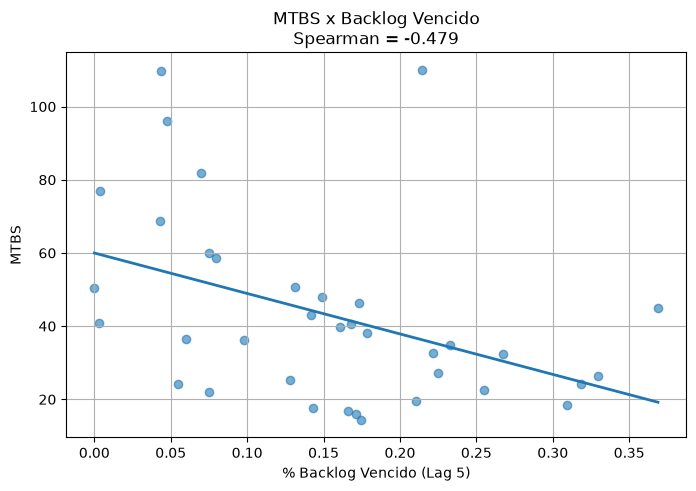

In [26]:
# =====================================================
# GRÁFICO 1
# MTBS x BACKLOG_PCT_VENCIDO_LAG5
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

dados = base[
    [
        "BACKLOG_PCT_VENCIDO_LAG5",
        "MTBS (REAL)"
    ]
].dropna()

# Correlação de Spearman

rho, p_valor = spearmanr(
    dados["BACKLOG_PCT_VENCIDO_LAG5"],
    dados["MTBS (REAL)"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    dados["BACKLOG_PCT_VENCIDO_LAG5"],
    dados["MTBS (REAL)"],
    alpha=0.6
)

z = np.polyfit(
    dados["BACKLOG_PCT_VENCIDO_LAG5"],
    dados["MTBS (REAL)"],
    1
)

p = np.poly1d(z)

x = np.linspace(
    dados["BACKLOG_PCT_VENCIDO_LAG5"].min(),
    dados["BACKLOG_PCT_VENCIDO_LAG5"].max(),
    100
)

plt.plot(
    x,
    p(x),
    linewidth=2
)

plt.xlabel("% Backlog Vencido (Lag 5)")
plt.ylabel("MTBS")

plt.title(
    f"MTBS x Backlog Vencido\nSpearman = {rho:.3f}"
)

plt.grid(True)

plt.show()

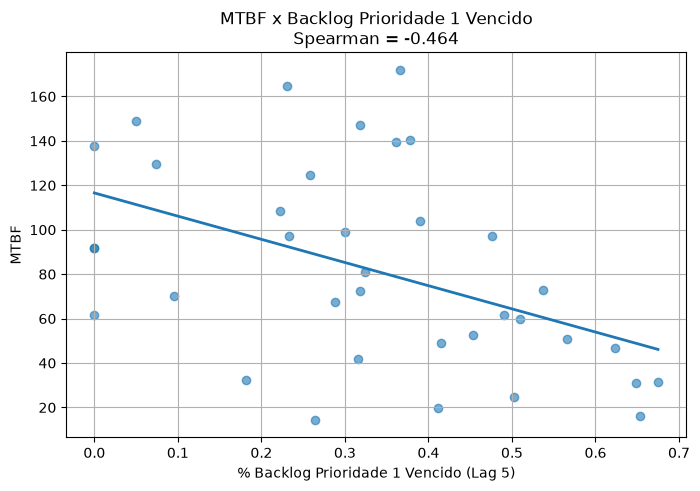

In [27]:
# =====================================================
# GRÁFICO 2
# MTBF x BACKLOG_PCT_PRIO1_VENCIDO_LAG5
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

dados = base[
    [
        "BACKLOG_PCT_PRIO1_VENCIDO_LAG5",
        "MTBF (REAL)"
    ]
].dropna()

# Correlação de Spearman

rho, p_valor = spearmanr(
    dados["BACKLOG_PCT_PRIO1_VENCIDO_LAG5"],
    dados["MTBF (REAL)"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    dados["BACKLOG_PCT_PRIO1_VENCIDO_LAG5"],
    dados["MTBF (REAL)"],
    alpha=0.6
)

z = np.polyfit(
    dados["BACKLOG_PCT_PRIO1_VENCIDO_LAG5"],
    dados["MTBF (REAL)"],
    1
)

p = np.poly1d(z)

x = np.linspace(
    dados["BACKLOG_PCT_PRIO1_VENCIDO_LAG5"].min(),
    dados["BACKLOG_PCT_PRIO1_VENCIDO_LAG5"].max(),
    100
)

plt.plot(
    x,
    p(x),
    linewidth=2
)

plt.xlabel("% Backlog Prioridade 1 Vencido (Lag 5)")
plt.ylabel("MTBF")

plt.title(
    f"MTBF x Backlog Prioridade 1 Vencido\nSpearman = {rho:.3f}"
)

plt.grid(True)

plt.show()

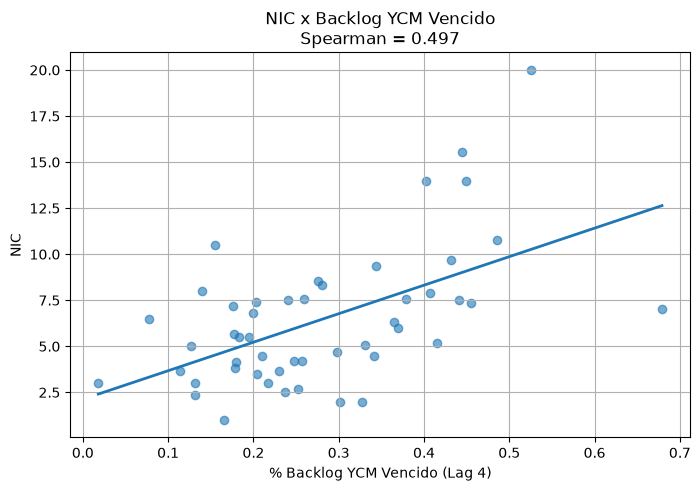

In [28]:
# =====================================================
# GRÁFICO 3
# NIC x BACKLOG_PCT_YCM_VENCIDO_LAG4
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

dados = base[
    [
        "BACKLOG_PCT_YCM_VENCIDO_LAG4",
        "NIC (VMINA)"
    ]
].dropna()

# Correlação de Spearman

rho, p_valor = spearmanr(
    dados["BACKLOG_PCT_YCM_VENCIDO_LAG4"],
    dados["NIC (VMINA)"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    dados["BACKLOG_PCT_YCM_VENCIDO_LAG4"],
    dados["NIC (VMINA)"],
    alpha=0.6
)

z = np.polyfit(
    dados["BACKLOG_PCT_YCM_VENCIDO_LAG4"],
    dados["NIC (VMINA)"],
    1
)

p = np.poly1d(z)

x = np.linspace(
    dados["BACKLOG_PCT_YCM_VENCIDO_LAG4"].min(),
    dados["BACKLOG_PCT_YCM_VENCIDO_LAG4"].max(),
    100
)

plt.plot(
    x,
    p(x),
    linewidth=2
)

plt.xlabel("% Backlog YCM Vencido (Lag 4)")
plt.ylabel("NIC")

plt.title(
    f"NIC x Backlog YCM Vencido\nSpearman = {rho:.3f}"
)

plt.grid(True)

plt.show()

<Figure size 800x500 with 0 Axes>

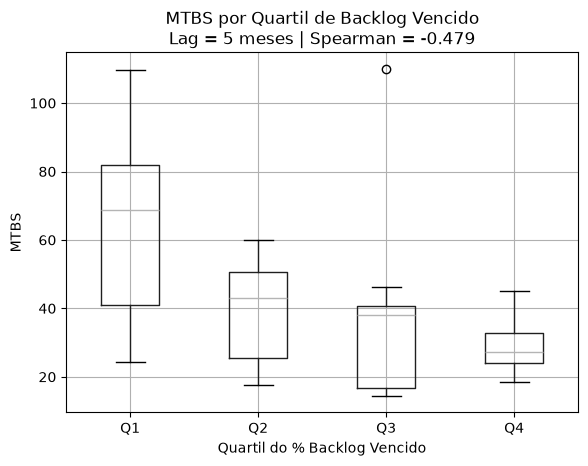

In [29]:
# =====================================================
# GRÁFICO 4
# BOXPLOT MTBS
# =====================================================

import matplotlib.pyplot as plt
from scipy.stats import spearmanr

dados = base[
    [
        "BACKLOG_PCT_VENCIDO_LAG5",
        "MTBS (REAL)"
    ]
].dropna()

# Correlação de Spearman

rho, p_valor = spearmanr(
    dados["BACKLOG_PCT_VENCIDO_LAG5"],
    dados["MTBS (REAL)"]
)

dados["FAIXA"] = pd.qcut(
    dados["BACKLOG_PCT_VENCIDO_LAG5"],
    q=4,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ]
)

plt.figure(figsize=(8,5))

dados.boxplot(
    column="MTBS (REAL)",
    by="FAIXA"
)

plt.title(
    f"MTBS por Quartil de Backlog Vencido\nLag = 5 meses | Spearman = {rho:.3f}"
)

plt.suptitle("")

plt.xlabel("Quartil do % Backlog Vencido")
plt.ylabel("MTBS")

plt.show()

<Figure size 800x500 with 0 Axes>

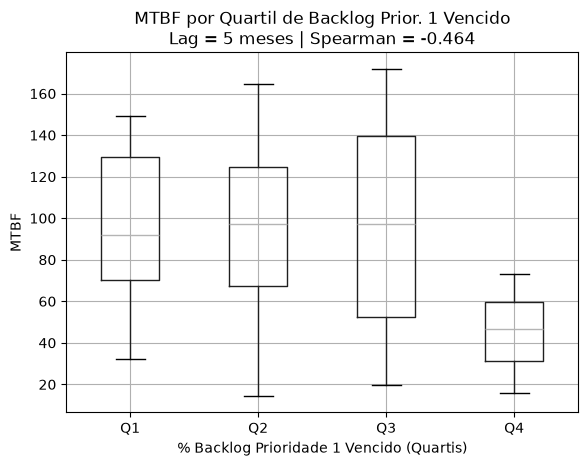

In [30]:
# =====================================================
# GRÁFICO 5
# BOXPLOT MTBF
# =====================================================

import matplotlib.pyplot as plt
from scipy.stats import spearmanr

dados = base[
    [
        "BACKLOG_PCT_PRIO1_VENCIDO_LAG5",
        "MTBF (REAL)"
    ]
].dropna()

# Correlação de Spearman

rho, p_valor = spearmanr(
    dados["BACKLOG_PCT_PRIO1_VENCIDO_LAG5"],
    dados["MTBF (REAL)"]
)

dados["FAIXA"] = pd.qcut(
    dados["BACKLOG_PCT_PRIO1_VENCIDO_LAG5"],
    q=4,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ]
)

plt.figure(figsize=(8,5))

dados.boxplot(
    column="MTBF (REAL)",
    by="FAIXA"
)

plt.title(
    f"MTBF por Quartil de Backlog Prior. 1 Vencido\nLag = 5 meses | Spearman = {rho:.3f}"
)

plt.suptitle("")

plt.xlabel("% Backlog Prioridade 1 Vencido (Quartis)")
plt.ylabel("MTBF")

plt.show()

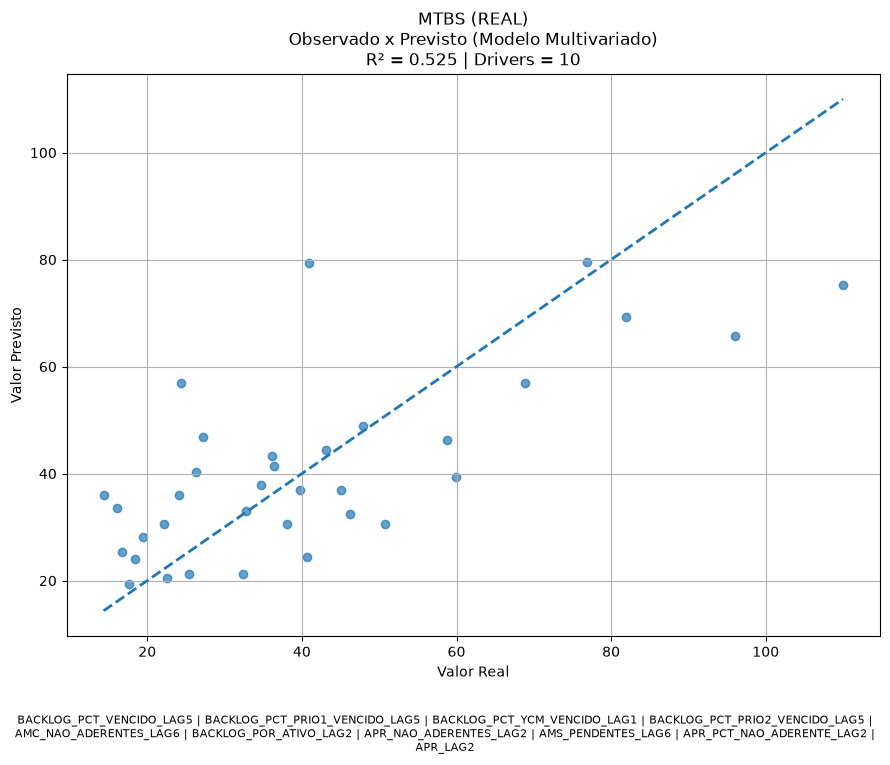

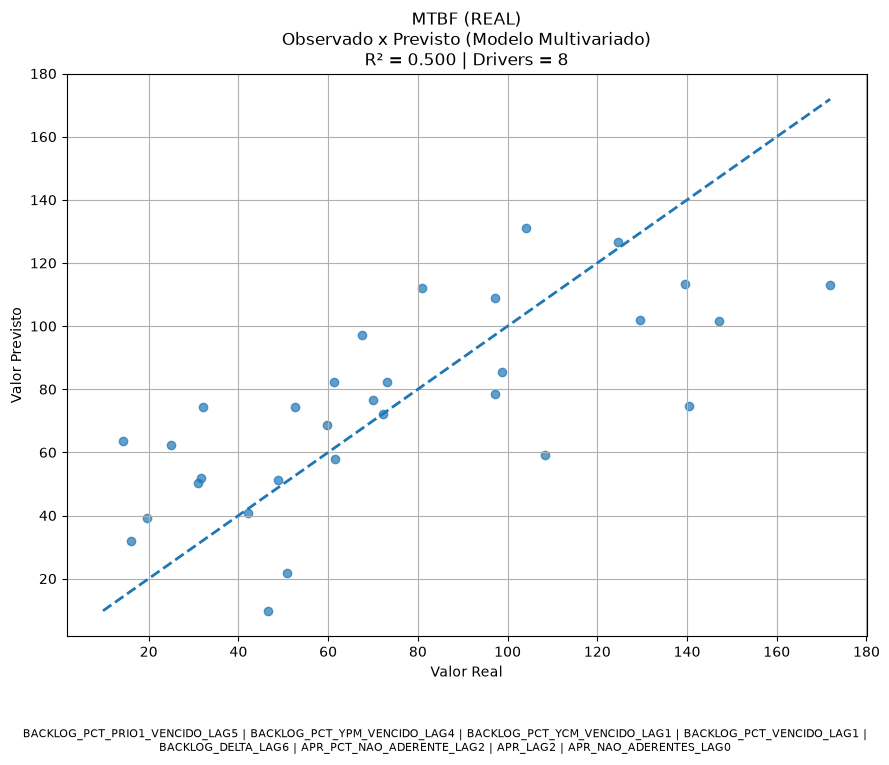

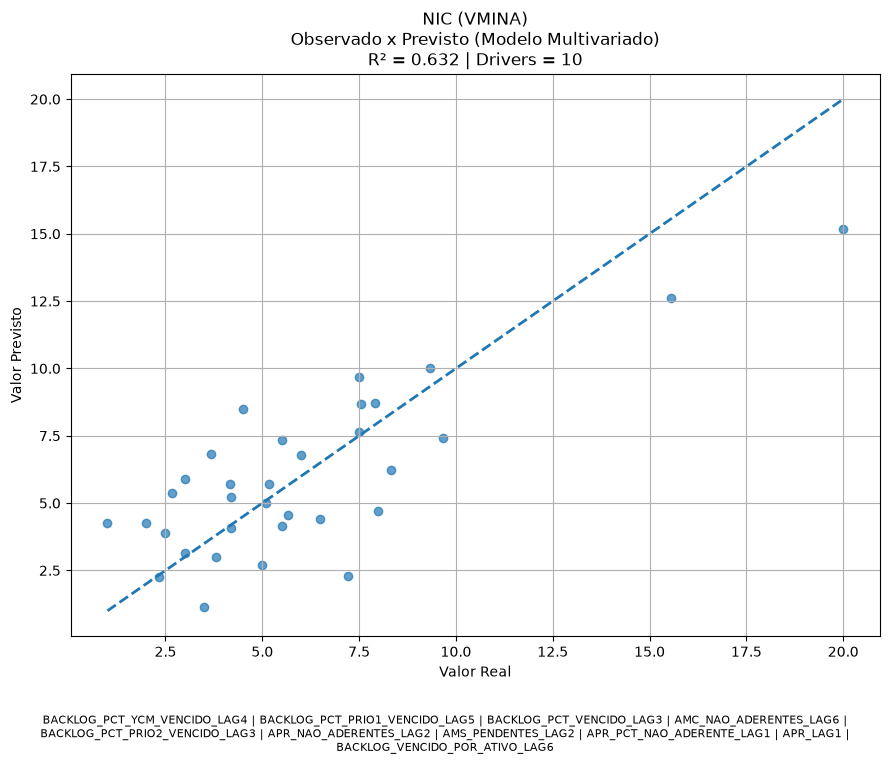

In [31]:
# ==========================================
# OBSERVADO x PREVISTO
# MTBS, MTBF e NIC
# ==========================================

import matplotlib.pyplot as plt
import statsmodels.api as sm

respostas = [
    "MTBS (REAL)",
    "MTBF (REAL)",
    "NIC (VMINA)"
]

for resposta in respostas:

    if resposta not in resultados_modelos:
        print(f"Modelo não encontrado: {resposta}")
        continue

    modelo = resultados_modelos[resposta]

    variaveis = [
        v
        for v in modelo.model.exog_names
        if v != "const"
    ]

    dados = (
        base[
            [resposta] + variaveis
        ]
        .dropna()
        .copy()
    )

    X = sm.add_constant(
        dados[variaveis],
        has_constant="add"
    )

    dados["PREVISTO"] = modelo.predict(X)

    r2 = modelo.rsquared

    plt.figure(figsize=(9, 7))

    plt.scatter(
        dados[resposta],
        dados["PREVISTO"],
        alpha=0.7
    )

    xmin = min(
        dados[resposta].min(),
        dados["PREVISTO"].min()
    )

    xmax = max(
        dados[resposta].max(),
        dados["PREVISTO"].max()
    )

    plt.plot(
        [xmin, xmax],
        [xmin, xmax],
        "--",
        linewidth=2
    )

    plt.title(
        f"{resposta}\n"
        f"Observado x Previsto (Modelo Multivariado)\n"
        f"R² = {r2:.3f} | Drivers = {len(variaveis)}",
        fontsize=12
    )

    plt.figtext(
        0.5,
        -0.08,
        " | ".join(variaveis),
        ha="center",
        fontsize=8,
        wrap=True
    )

    plt.xlabel("Valor Real")
    plt.ylabel("Valor Previsto")

    plt.grid(True)

    plt.tight_layout()

    plt.show()